# Project 5B: Flow Matching from Scratch!

## Setup environment

In [ ]:
# We recommend using these utils.
# https://google.github.io/mediapy/mediapy.html
# https://einops.rocks/
!pip install mediapy einops --quiet

In [ ]:
# Import essential modules. Feel free to add whatever you need.
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from tqdm import tqdm

## Neural Network Resources

In this part, you will build and train a [UNet](https://arxiv.org/abs/1505.04597), which is more complex than the MLP you implemented in the NeRF project.  We provide all class definitions you may need (but feel free to add or modify them as necessary).  

Instead of asking ChatGPT to write everything for you, please consult the following resources when you get stuck — they will help you understand how and why things work under the hood.

- PyTorch Documentation — [`Conv2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html), [`ConvTranspose2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html), and [`AvgPool2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.AvgPool2d.html).
- PyTorch Documentation - [`torchvision.datasets.MNIST`](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.MNIST.html), the dataset we gonna use, and [`torch.utils.data.DataLoader`](https://docs.pytorch.org/docs/stable/data.html), the off-the-shell dataloader we can directly use.
- PyTorch [tutorial](https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html) on how to train a classifier on CIFAR10 dataset. The structure of your training code will be very similar to this one.

# Part 1: Training a Single-step Denoising UNet


# Part 1.1: Implementing the UNet

## Implementing Simple and Composed Ops

In [ ]:
import torch

class Conv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride = 1, padding=1)
        self.bn = nn.BatchNorm2d(out_channels)
        self.activation = nn.GELU()

        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        x = self.conv(x)
        x = self.bn(x)
        x = self.activation(x)
        return x
        # ===== end of code ====


class DownConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride = 2, padding=1)
        self.bn = nn.BatchNorm2d(out_channels)
        self.activation = nn.GELU()
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        x = self.conv(x)
        x = self.bn(x)
        x = self.activation(x)
        return x
        # ===== end of code ====



class UpConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.conv = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride =2, padding=1)
        self.bn = nn.BatchNorm2d(out_channels)
        self.activation = nn.GELU()

        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        x = self.conv(x)
        x = self.bn(x)
        x = self.activation(x)
        return x
        # ===== end of code ====


class Flatten(nn.Module):
    def __init__(self):
        super().__init__()
        # ===== your code here! ====
        self.pool = nn.AvgPool2d(kernel_size=7)
        self.activation = nn.GELU()

        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        x = self.pool(x)
        x = self.activation(x)
        return x
        # ===== end of code ====


class Unflatten(nn.Module):
    def __init__(self, in_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.conv = nn.ConvTranspose2d(in_channels, in_channels, kernel_size=7, stride =7, padding=0)
        self.bn = nn.BatchNorm2d(in_channels)
        self.activation = nn.GELU()
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        x = self.conv(x)
        x = self.bn(x)
        x = self.activation(x)
        return x
        # ===== end of code ====


class ConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.conv1 = Conv(in_channels, out_channels)
        self.conv2 = Conv(out_channels, out_channels)
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        x = self.conv1(x)
        x = self.conv2(x)
        return x
        # ===== end of code ====


class DownBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.conv1 = DownConv(in_channels, out_channels)
        self.conv2 = ConvBlock(out_channels, out_channels)
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        x = self.conv1(x)
        x = self.conv2(x)
        return x
        # ===== end of code ====


class UpBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.conv1 = UpConv(in_channels, out_channels)
        self.conv2 = ConvBlock(out_channels, out_channels)
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        x = self.conv1(x)
        x = self.conv2(x)
        return x
        # ===== end of code ====


## Implementing Unconditional UNet

In [ ]:
class UnconditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_hiddens: int,
    ):
        super().__init__()
        # ===== your code here! ====
        D = num_hiddens
        self.inc = ConvBlock(in_channels, D)
        self.down1 = DownBlock(D, D)
        self.down2 = DownBlock(D, 2*D)
        self.flatten = Flatten()
        self.unflatten = Unflatten(2*D)
        self.up1 = UpBlock(4*D, D)
        self.up2 = UpBlock(2*D, D)
        self.outc = ConvBlock(2*D, D)
        self.final = nn.Conv2d(D, in_channels, kernel_size=3, stride=1, padding=1)

        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."
        # ===== your code here! ====
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        flat = self.flatten(x3)
        unflat = self.unflatten(flat)
        cat6 = torch.cat([unflat, x3], dim=1)
        x7 = self.up1(cat6)
        cat8 = torch.cat([x2, x7], dim=1)
        x9 = self.up2(cat8)
        cat10 = torch.cat([x1, x9], dim=1)
        x11 = self.outc(cat10)
        x12 = self.final(x11)
        return x12

        # ===== end of code ====

# Part 1.2: Using the UNet to Train a Denoiser

In [ ]:
# Visualize images at different noisy level
# ===== your code here! ====
import torch
import matplotlib.pyplot as plt
import numpy as np

def noise_visualization(image, sigmas=[0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]):
  fig, axes = plt.subplots(1, len(sigmas), figsize=(2*len(sigmas), 2))

  for i, sigma in enumerate(sigmas):
    noisy_image = image + sigma * torch.randn_like(image)
    axes[i].imshow(noisy_image.squeeze().numpy(), cmap='gray')
    axes[i].set_title(f"σ = {sigma}")
    axes[i].axis('off')

  plt.show()



# ===== end of code ====

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.02MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.51MB/s]


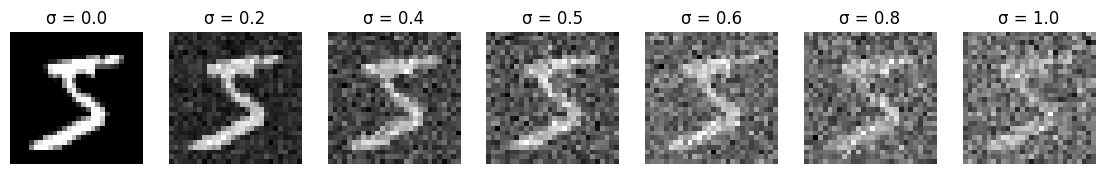

In [ ]:
from torchvision import datasets, transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

mnist = datasets.MNIST(root="./data", download=True, train=True, transform=transform)
image, _ = mnist[0]

noise_visualization(image)

## Part 1.2.1: Training

For this part, we provide some structure code for training. It is very basic, so feel free to change them or add your code. In later section we won't provide any training or visualization structure code.

In [ ]:
import torchvision
import torch.optim as optim

device = torch.device('cuda')

# Set your hyperparameters
# ===== your code here! ====
batch_size = 256
learning_rate = 1e-4
noise_level = 0.5
hidden_dim = 128
num_epochs = 5
# ===== end of code ====

In [ ]:
# Define your datasets and dataloaders
# ===== your code here! ====
transform = transforms.Compose([
    transforms.ToTensor(),
])
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
# ===== end of code ====

In [ ]:
# Define your model, optimizer, and loss
# ===== your code here! ====
model = UnconditionalUNet(in_channels=1, num_hiddens=hidden_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()
# ===== end of code ====

In [ ]:
import matplotlib.pyplot as plt

def visualize_denoise_results(epoch, model, test_loader, device,  num_samples=8):
  model.eval()
  with torch.no_grad():
      images, _ = next(iter(test_loader))
      images = images[:num_samples].to(device)
      epsilon = torch.randn_like(images)
      noisy_images = images + noise_level * epsilon
      outputs = model(noisy_images)

      images = images.cpu()
      noisy_images = noisy_images.cpu()
      outputs = outputs.cpu()

      fig, axes = plt.subplots(3, num_samples, figsize=(16, 6))

      for i in range(num_samples):
            # Clean images (top row)
            axes[0, i].imshow(images[i].squeeze(), cmap='gray')
            axes[0, i].axis('off')
            if i == 0:
                axes[0, i].set_ylabel('Clean')

            # Noisy images (middle row)
            axes[1, i].imshow(noisy_images[i].squeeze(), cmap='gray')
            axes[1, i].axis('off')
            if i == 0:
                axes[1, i].set_ylabel('Noisy')

            # Denoised images (bottom row)
            axes[2, i].imshow(outputs[i].squeeze(), cmap='gray')
            axes[2, i].axis('off')
            if i == 0:
                axes[2, i].set_ylabel('Denoised')

      plt.suptitle(f'Denoising Results - Epoch {epoch} (σ={noise_level})', fontsize=16)
      plt.tight_layout()
      plt.show()

  model.train()


  0%|          | 1/235 [00:01<06:59,  1.79s/it]

Epoch 1, Batch 0, Loss: 0.255962


 43%|████▎     | 101/235 [00:40<00:54,  2.48it/s]

Epoch 1, Batch 100, Loss: 0.014150


 86%|████████▌ | 201/235 [01:21<00:14,  2.30it/s]

Epoch 1, Batch 200, Loss: 0.012998


100%|██████████| 235/235 [01:36<00:00,  2.43it/s]


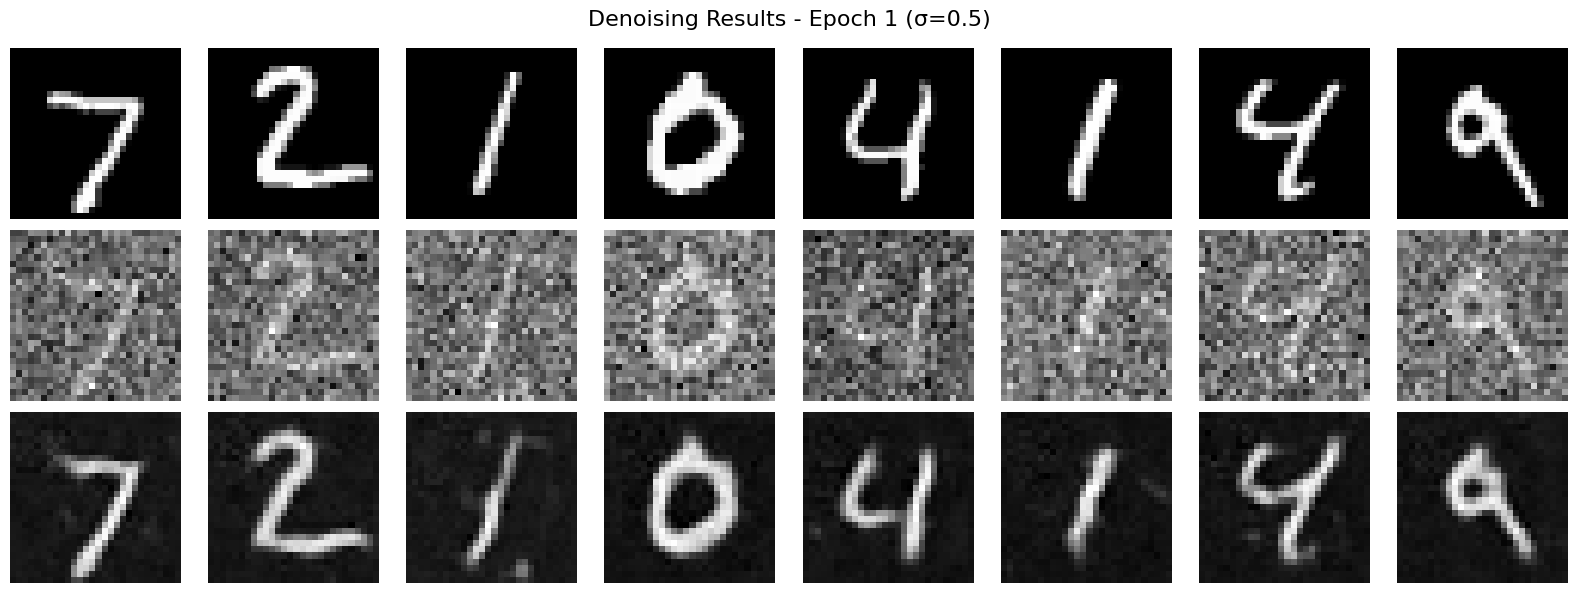

  0%|          | 1/235 [00:00<02:18,  1.69it/s]

Epoch 2, Batch 0, Loss: 0.012905


 43%|████▎     | 101/235 [00:44<00:56,  2.35it/s]

Epoch 2, Batch 100, Loss: 0.011729


 86%|████████▌ | 201/235 [01:27<00:15,  2.26it/s]

...

 43%|████▎     | 101/235 [00:43<00:57,  2.32it/s]

Epoch 5, Batch 100, Loss: 0.008167


 86%|████████▌ | 201/235 [01:27<00:14,  2.30it/s]

Epoch 5, Batch 200, Loss: 0.008117


100%|██████████| 235/235 [01:41<00:00,  2.31it/s]


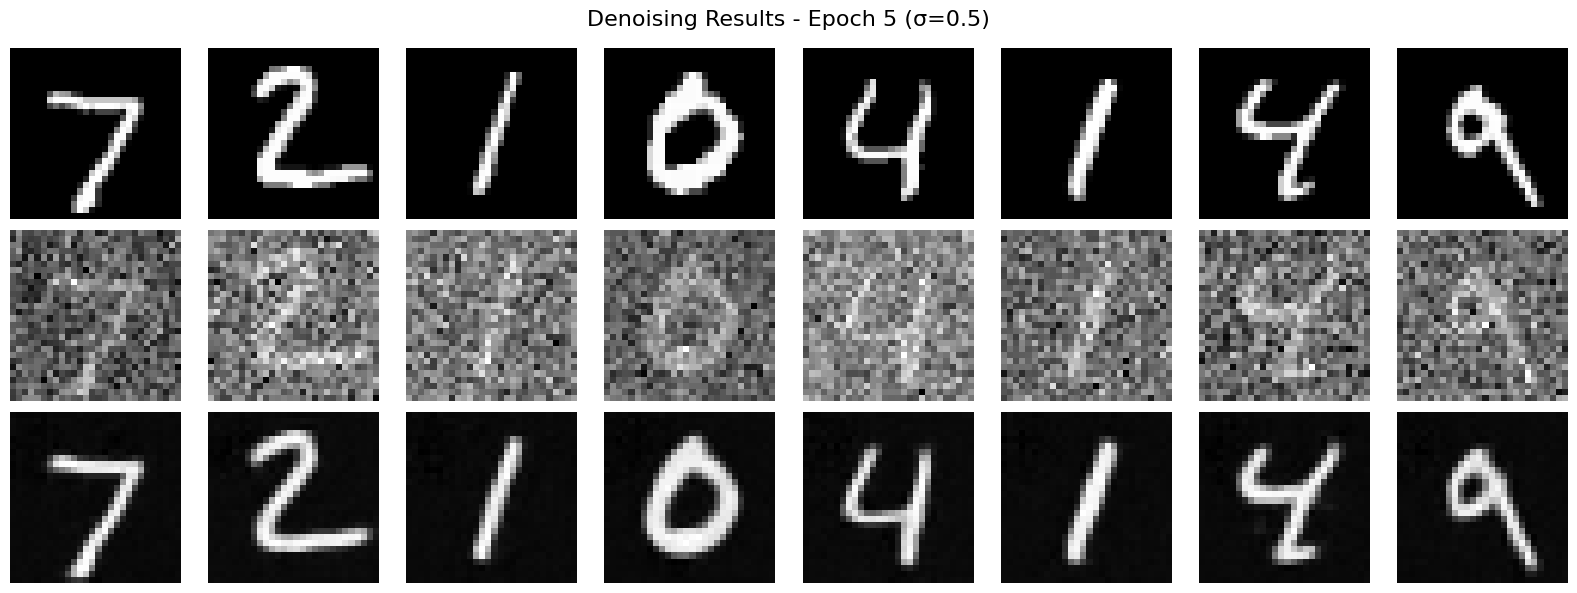

In [ ]:
# The training loops
train_losses = []
for epoch in range(num_epochs):
    model.train()

    for i, (images, _) in enumerate(tqdm(train_loader)):

        # ===== your code here! ====
        images = images.to(device)
        epsilon = torch.randn_like(images)
        noisy_images = images + epsilon * noise_level

        outputs = model(noisy_images)
        # ===== end of code ====

        loss = criterion(outputs, images)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        if i % 100 == 0:
             print(f'Epoch {epoch+1}, Batch {i}, Loss: {loss.item():.6f}')
    if epoch == 0 or epoch == num_epochs - 1:
       visualize_denoise_results(epoch + 1, model, test_loader, device)


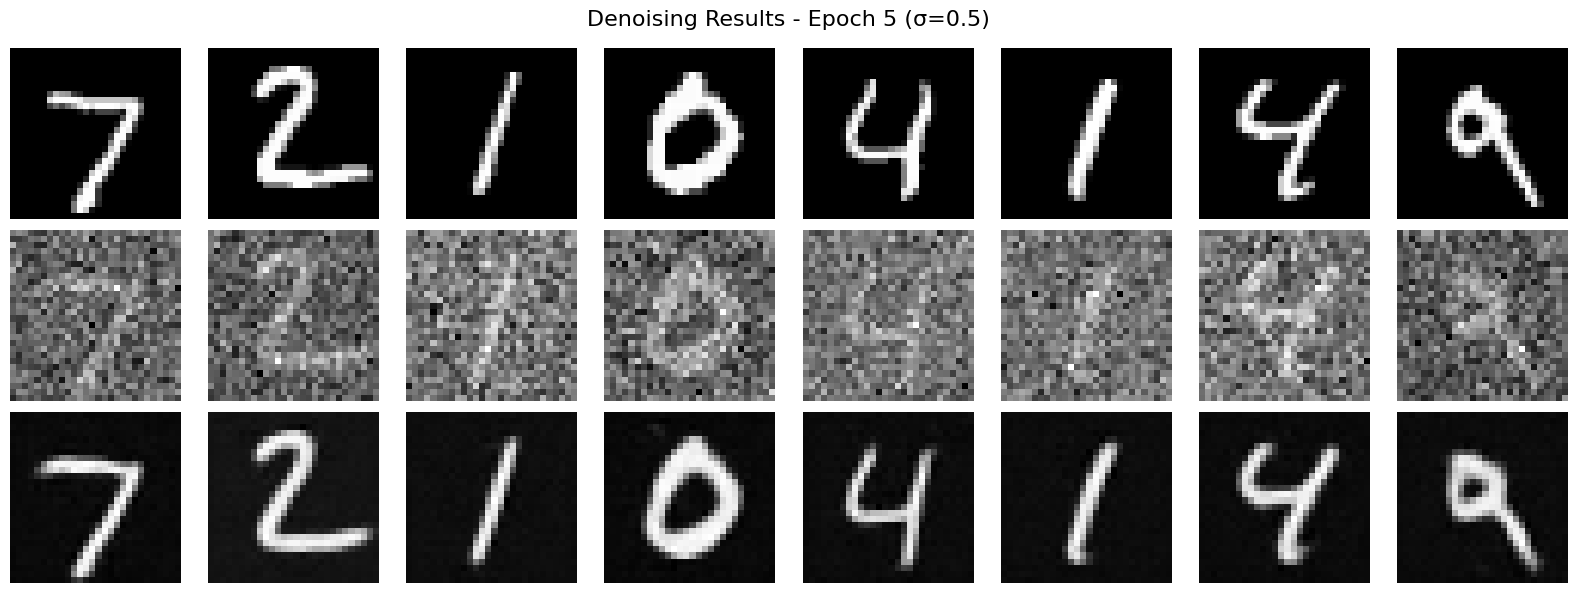

In [ ]:
visualize_denoise_results(epoch + 1, model, test_loader, device)


In [ ]:
torch.save(model.state_dict(), "model_t3.pth")

In [ ]:
model_saved = torch.load("model.pth", weights_only=False)
model_saved.eval()


UnconditionalUNet(
  (inc): ConvBlock(
    (conv1): Conv(
      (conv): Conv2d(1, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (activation): GELU(approximate='none')
    )
    (conv2): Conv(
      (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (activation): GELU(approximate='none')
    )
  )
  (down1): DownBlock(
    (conv1): DownConv(
      (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (activation): GELU(approximate='none')
    )
    (conv2): ConvBlock(
      (conv1): Conv(
        (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, 

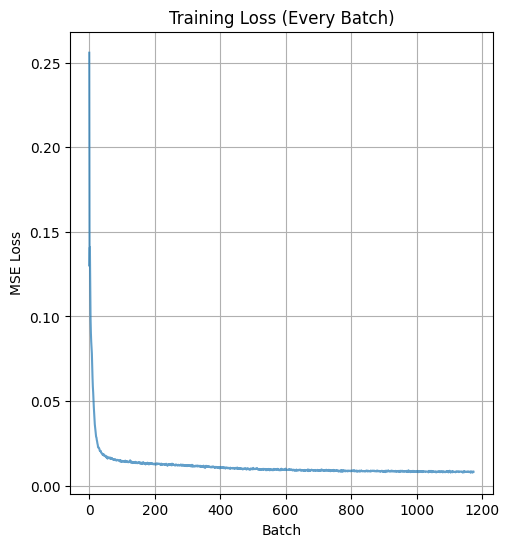

In [ ]:
# Visualize your training curve
# ===== your code here! ====
plt.figure(figsize=(12, 6))

# Plot all losses (every batch)
plt.subplot(1, 2, 1)
plt.plot(train_losses, alpha=0.7)
plt.xlabel('Batch')
plt.ylabel('MSE Loss')
plt.title('Training Loss (Every Batch)')
plt.grid(True)
# ===== end of code ====

## Part 1.2.2: Out-of-Distribution Testing

In [ ]:
# Visualize OOD testing
# ===== your code here! ====
def visualize_ood_denoising(model, test_loader, device, sigmas=[0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0], num_samples=4):
    model.eval()
    with torch.no_grad():
        images, _ = next(iter(test_loader))
        images = images[:num_samples].to(device)

        # Create figure with rows = sigmas, columns = digits
        fig, axes = plt.subplots(num_samples, len(sigmas), figsize=(2*len(sigmas), 2*num_samples))

        for j, sigma in enumerate(sigmas):
            epsilon = torch.randn_like(images)
            noisy_images = images + sigma * epsilon
            denoised = model(noisy_images)

            denoised_cpu = torch.clamp(denoised.cpu(), 0, 1)

            for i in range(num_samples):
                axes[i, j].imshow(denoised_cpu[i].squeeze(), cmap="gray", vmin=0, vmax=1)
                axes[i, j].axis('off')

                # Add sigma labels at the top (first row)
                if i == 0:
                    axes[i, j].set_title(f'σ={sigma}', fontsize=12, pad=10)

                # Add digit labels on the left (first column)
                if j == 0:
                    axes[i, j].set_ylabel(f'Digit {i+1}', rotation=0, ha='right', va='center', fontsize=12)

        plt.suptitle('Out-of-Distribution Denoising Performance (Model trained on σ=0.5)', fontsize=16, y=0.95)
        plt.show()

# ===== end of code ====

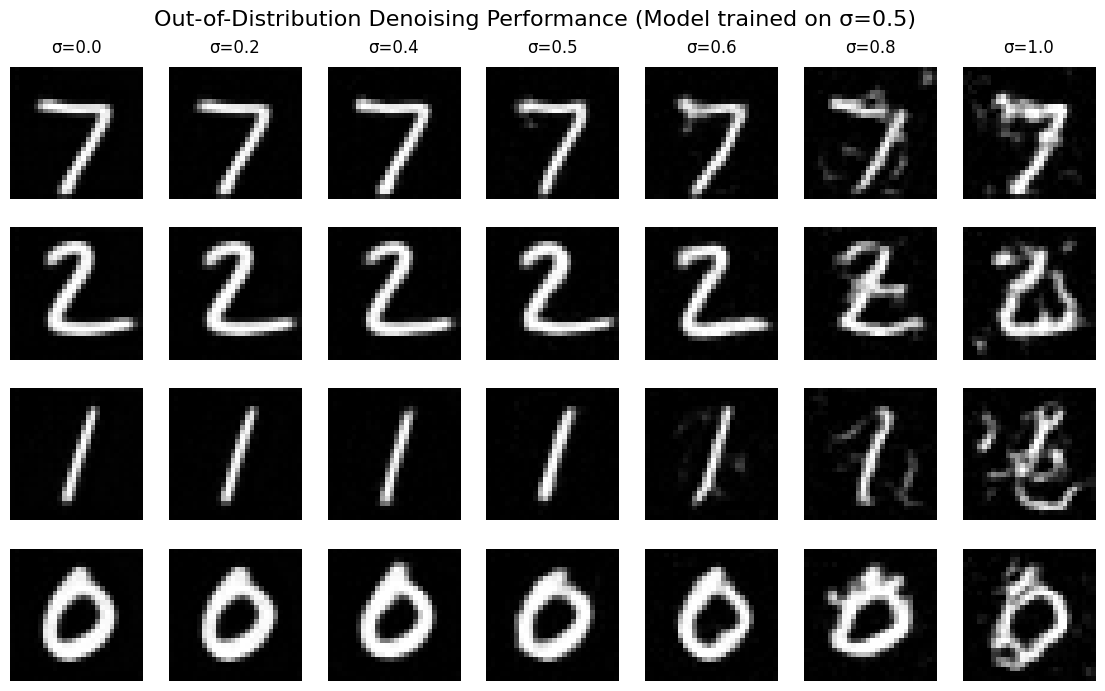

In [ ]:
visualize_ood_denoising(model, test_loader, device)

## Part 1.2.3 Denoising Pure Noise

In [ ]:
import matplotlib.pyplot as plt

def visualize_pure_noise_results(epoch, model, device,  num_samples=8):
  model.eval()
  with torch.no_grad():
      epsilon = torch.randn(num_samples, 1, 28, 28).to(device)
      outputs = model(epsilon)

      epsilon = epsilon.cpu()
      outputs = outputs.cpu()

      fig, axes = plt.subplots(2, num_samples, figsize=(16, 4))

      for i in range(num_samples):
            # Noisy images (middle row)
            axes[0, i].imshow(epsilon[i].squeeze(), cmap='gray')
            axes[0, i].axis('off')
            if i == 0:
                axes[0, i].set_ylabel('Pure Noise')

            # Denoised images (bottom row)
            axes[1, i].imshow(outputs[i].squeeze(), cmap='gray')
            axes[1, i].axis('off')
            if i == 0:
                axes[1, i].set_ylabel('Generated')

      plt.suptitle(f'Pure Noise Denoising - Epoch {epoch} ', fontsize=16)
      plt.tight_layout()
      plt.show()

  model.train()


In [ ]:
# Define your model, optimizer, and loss
# ===== your code here! ====
model = UnconditionalUNet(in_channels=1, num_hiddens=hidden_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()
# ===== end of code ====

In [ ]:
# Feel free to use code from part 1.2.1
# as they should be very similar
# ===== your code here! ====
# The training loops
train_losses = []
for epoch in range(num_epochs):
    model.train()

    for i, (images, _) in enumerate(tqdm(train_loader)):

        # ===== your code here! ====
        images = images.to(device)
        noise = torch.randn_like(images)

        outputs = model(noise)
        # ===== end of code ====

        loss = criterion(outputs, images)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        if i % 100 == 0:
             print(f'Epoch {epoch+1}, Batch {i}, Loss: {loss.item():.6f}')
    if epoch == 0 or epoch == num_epochs - 1:
       visualize_denoise_results(epoch + 1, model, test_loader, device)

# ===== end of code ====

  0%|          | 1/235 [00:01<06:40,  1.71s/it]

Epoch 1, Batch 0, Loss: 0.292463


  6%|▌         | 14/235 [00:06<01:46,  2.08it/s]


KeyboardInterrupt: 

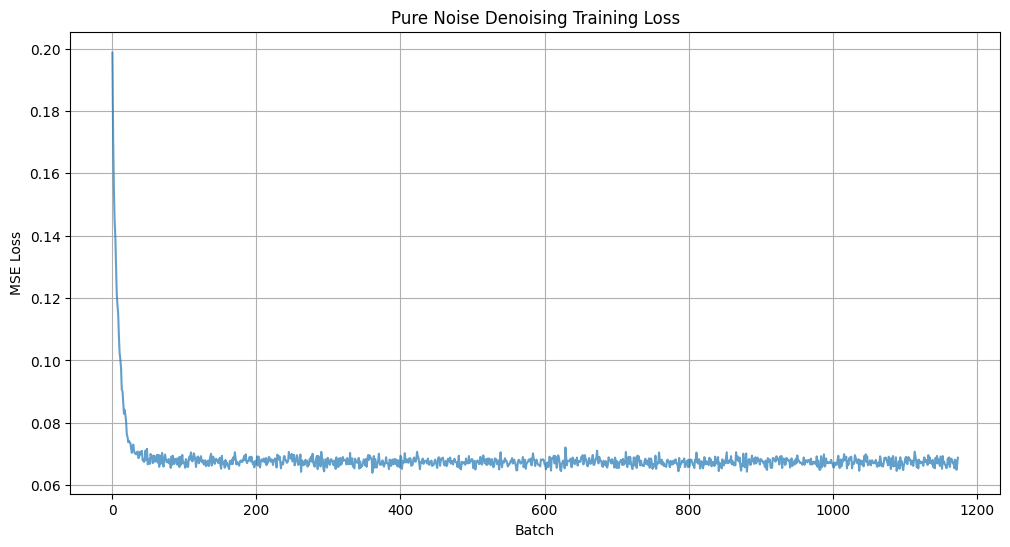

Pure noise denoising training completed!


In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(train_losses, alpha=0.7)
plt.xlabel('Batch')
plt.ylabel('MSE Loss')
plt.title('Pure Noise Denoising Training Loss')
plt.grid(True)
plt.show()

print("Pure noise denoising training completed!")
# ===== end of code ====

In [ ]:
torch.save(model.state_dict(), "model_1.2.3.pth")

# Part 2: Flow Matching

# Part 2.1: Implementing a Time-conditioned UNet

In [ ]:
class FCBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # ===== your code here! ====
        self.fc1 = nn.Linear(in_channels, out_channels)
        self.GELU = nn.GELU()
        self.fc2 = nn.Linear(out_channels, out_channels)
        # ===== end of code ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ===== your code here! ====
        x = self.fc1(x)
        x = self.GELU(x)
        x = self.fc2(x)
        return x
        # ===== end of code ====


class TimeConditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_classes: int,
        num_hiddens: int,
    ):
        super().__init__()
        # ===== your code here! ====
        D = num_hiddens
        self.inc = ConvBlock(in_channels, D)
        self.down1 = DownBlock(D, D)
        self.down2 = DownBlock(D, 2*D)
        self.flatten = Flatten()
        self.unflatten = Unflatten(2*D)
        self.up1 = UpBlock(4*D, D)
        self.up2 = UpBlock(2*D, D)
        self.outc = ConvBlock(2*D, D)
        self.final = nn.Conv2d(D, in_channels, kernel_size=3, stride=1, padding=1)

        self.fc2 = FCBlock(1, D)
        self.fc1 = FCBlock(1, 2 * D)


        # ===== end of code ====

    def forward(
        self,
        x: torch.Tensor,
        t: torch.Tensor,
    ) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            t: (N,) normalized time tensor.

        Returns:
            (N, C, H, W) output tensor.
        """
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."
        # ===== your code here! ====
        t = t.unsqueeze(-1)

        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        flat = self.flatten(x3)
        unflat = self.unflatten(flat)

        t1 = self.fc1(t).unsqueeze(-1).unsqueeze(-1)
        unflat = unflat * t1
        cat6 = torch.cat([unflat, x3], dim=1)
        x7 = self.up1(cat6)

        t2 = self.fc2(t).unsqueeze(-1).unsqueeze(-1)
        x7 = x7 * t2
        cat8 = torch.cat([x2, x7], dim=1)
        x9 = self.up2(cat8)
        cat10 = torch.cat([x1, x9], dim=1)
        x11 = self.outc(cat10)
        x12 = self.final(x11)
        return x12
        # ===== end of code ====


## Implementing the Forward and Reverse Process for Time-conditioned Denoising

In [ ]:
def time_fm_forward(
    unet: TimeConditionalUNet,
    x_1: torch.Tensor,
    num_ts: int,
) -> torch.Tensor:
    """Algorithm 1

    Args:
        unet: TimeConditionalUNet
        x_1: (N, C, H, W) input tensor.
        num_ts: int, number of timesteps.
    Returns:
        (,) loss.
    """
    unet.train()
    # ===== your code here! ====
    batch_size = x_1.shape[0]
    device = x_1.device
    t = torch.rand(batch_size, device=device)
    x_0 = torch.randn_like(x_1)
    x_t = (1 - t.view(-1, 1, 1, 1)) * x_0 + t.view(-1, 1, 1, 1) * x_1
    true_float = x_1 - x_0
    predicted_flow = unet(x_t, t)
    loss = torch.mean((predicted_flow - true_float) ** 2)
    return loss
    # ===== end of code ====


In [ ]:
@torch.inference_mode()
def time_fm_sample(
    unet: TimeConditionalUNet,
    img_wh: tuple[int, int],
    num_ts: int,
    seed: int = 0,
) -> torch.Tensor:
    """Algorithm 2

    Args:
        unet: TimeConditionalUNet
        img_wh: (H, W) output image width and height.
        num_ts: int, number of timesteps.
        seed: int, random seed.

    Returns:
        (N, C, H, W) final sample.
    """
    unet.eval()
    # ===== your code here! ====
    if seed is not None:
        torch.manual_seed(seed)

    H, W = img_wh
    device = next(unet.parameters()).device
    x_t = torch.randn(1, 1, H, W, device=device)

    dt = 1.0 / num_ts
    for i in range(num_ts):
        t = i * dt
        flow = unet(x_t, torch.tensor([t], device=device))
        x_t = x_t + flow*dt

    return x_t
    # ===== end of code ====


In [ ]:
class TimeConditionalFM(nn.Module):
    def __init__(
        self,
        unet: TimeConditionalUNet,
        num_ts: int = 50,
        img_hw: tuple[int, int] = (28, 28),
    ):
        super().__init__()

        self.unet = unet
        self.num_ts = num_ts
        self.img_hw = img_hw


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.

        Returns:
            (,) diffusion loss.
        """
        return time_fm_forward(
            self.unet, x, self.num_ts
        )


    @torch.inference_mode()
    def sample(
        self,
        img_wh: tuple[int, int],
        seed: int = 0,
    ):
        return time_fm_sample(
            self.unet, img_wh, self.num_ts, seed
        )


# Part 2.2: Training the Time-conditioned UNet

In [ ]:
import torchvision
import torch.optim as optim

device = torch.device('cuda')

# Set your hyperparameters
batch_size = 64
learning_rate = 1e-2
hidden_dim = 64
num_epochs = 10
gamma = 0.1**(1.0/num_epochs)
# Define your datasets and dataloaders
transform = transforms.Compose([
    transforms.ToTensor(),
])
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
# ===== end of code ====
# Define your model, optimizer, and loss
# ===== your code here! ====
model = TimeConditionalUNet(in_channels=1, num_classes=10, num_hiddens=hidden_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)
criterion = nn.MSELoss()
# ===== end of code ====

In [ ]:
visualization_freq = 5
num_samples_to_visualize = 40

def visualize_samples(model, epoch, num_samples=40):
    model.eval()
    with torch.no_grad():
        samples = []
        for _ in range(4):  # 4 rows
            for class_label in range(10):  # 10 columns
                c = torch.tensor([class_label], device=device)
                sample = class_fm_sample(model, c=c, img_wh=(28, 28), num_ts=50, seed=epoch*100 + class_label)
                samples.append(sample)

        samples_batch = torch.cat(samples, dim=0)
        samples_batch = torch.clamp(samples_batch.cpu(), 0, 1)

    n_rows, n_cols = 4, 10
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 10))
    axes_flat = axes.flatten()

    for i in range(num_samples):
        axes_flat[i].imshow(samples_batch[i].squeeze(), cmap='gray')
        axes_flat[i].axis('off')

    plt.subplots_adjust(wspace=0.05, hspace=0.05)
    plt.suptitle(f'Generated Digits - Epoch {epoch}', fontsize=24, y=0.98)
    plt.tight_layout()

    plt.show(block=False)
    plt.pause(0.1)

    plt.close(fig)

    model.train()
    return samples_batch


In [ ]:
import os
import torch

checkpoint_dir = './checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

checkpoint_epochs = [1, 5, 10]
num_samples_to_generate = 40
sampling_results = {}


train_losses = []
print("Starting flow matching training...")

for epoch in range(num_epochs):
    model.train()
    epoch_losses = []

    for i, (images, _) in enumerate(tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')):
        images = images.to(device)
        loss = time_fm_forward(model, images, num_ts=50)

        # ===== END FLOW MATCHING =====

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        epoch_losses.append(loss.item())

        if i % 100 == 0:
            print(f'Epoch {epoch+1}, Batch {i}, Loss: {loss.item():.6f}, LR: {scheduler.get_last_lr()[0]:.6f}')

    scheduler.step()

    avg_epoch_loss = sum(epoch_losses) / len(epoch_losses)
    print(f'Epoch {epoch+1} completed. Average Loss: {avg_epoch_loss:.6f}, LR: {scheduler.get_last_lr()[0]:.6f}')

    if (epoch + 1) % visualization_freq == 0 or epoch == 0:
        print(f"\nEpoch {epoch + 1}: Generating samples for visualization...")
        visualize_samples(model, epoch + 1, num_samples_to_visualize)

    # Visualization
    if (epoch + 1) in checkpoint_epochs:
        checkpoint_path = os.path.join(checkpoint_dir, f'epoch_{epoch+1}.pt')
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'loss': avg_epoch_loss,
        }, checkpoint_path)
        print(f"Checkpoint saved at {checkpoint_path}")

        model.eval()
        with torch.no_grad():
            samples = []
            for seed in range(8):
                sample = time_fm_sample(model, img_wh=(28, 28), num_ts=50, seed=seed)
                samples.append(sample)

            samples_batch = torch.cat(samples, dim=0)
            sampling_results[epoch + 1] = samples_batch.cpu()

        model.train()

Starting flow matching training...


Epoch 1/10:   0%|          | 3/938 [00:00<01:54,  8.16it/s]

Epoch 1, Batch 0, Loss: 1.399312, LR: 0.010000


Epoch 1/10:  11%|█         | 104/938 [00:04<00:34, 23.89it/s]

Epoch 1, Batch 100, Loss: 0.256290, LR: 0.010000


Epoch 1/10:  16%|█▋        | 153/938 [00:06<00:35, 22.14it/s]


KeyboardInterrupt: 

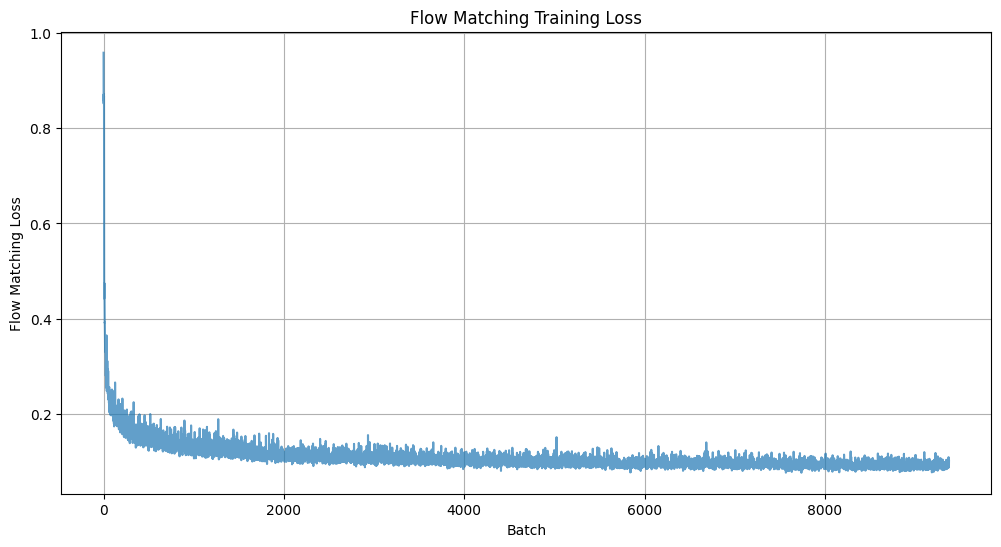

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(train_losses[2:], alpha=0.7)
plt.xlabel('Batch')
plt.ylabel('Flow Matching Loss')
plt.title('Flow Matching Training Loss')
plt.grid(True)
plt.show()

In [ ]:
checkpoint_path = os.path.join(checkpoint_dir, f'epoch_{epoch+1}.pt')
torch.save({
    'epoch': epoch + 1,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    'loss': avg_epoch_loss,
}, checkpoint_path)


Generating samples from checkpoints...
Generated 40 samples from epoch 1
Generated 40 samples from epoch 5
Generated 40 samples from epoch 10


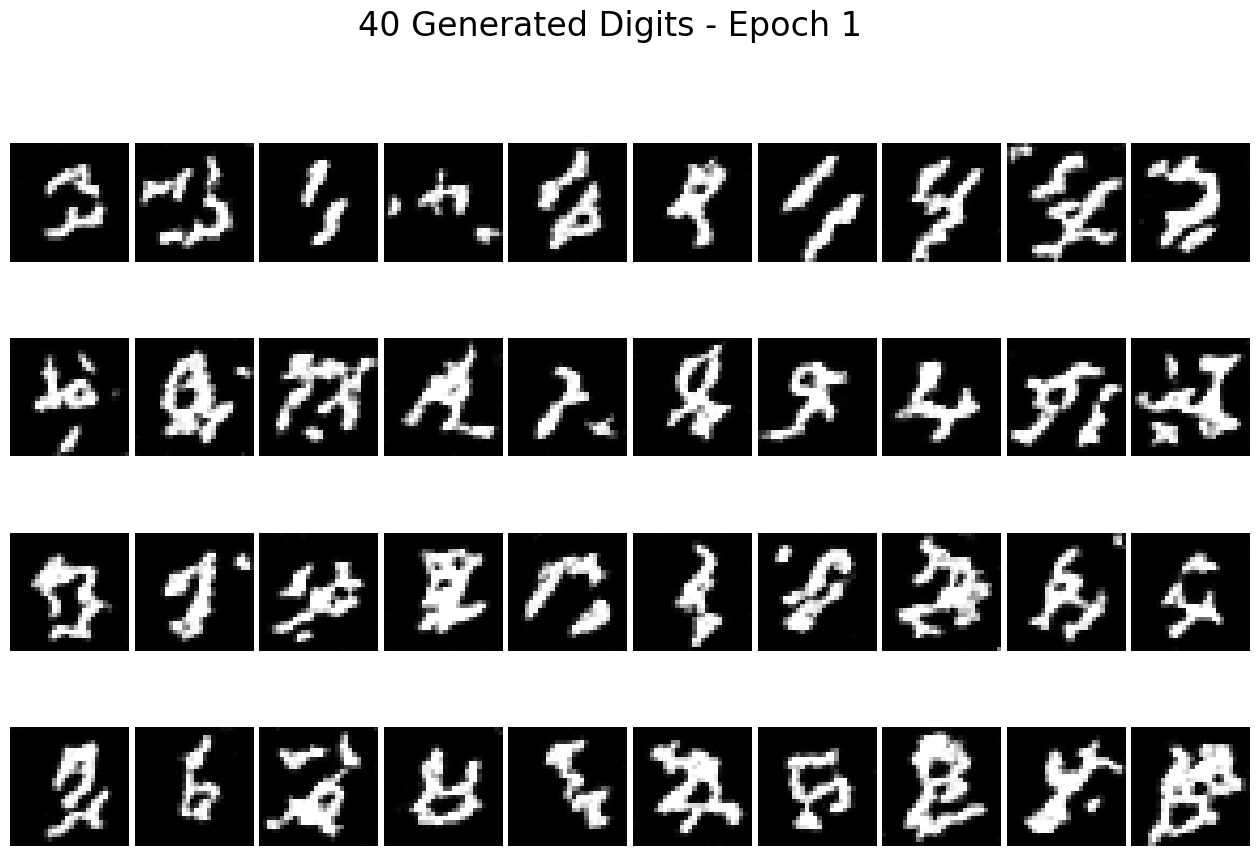

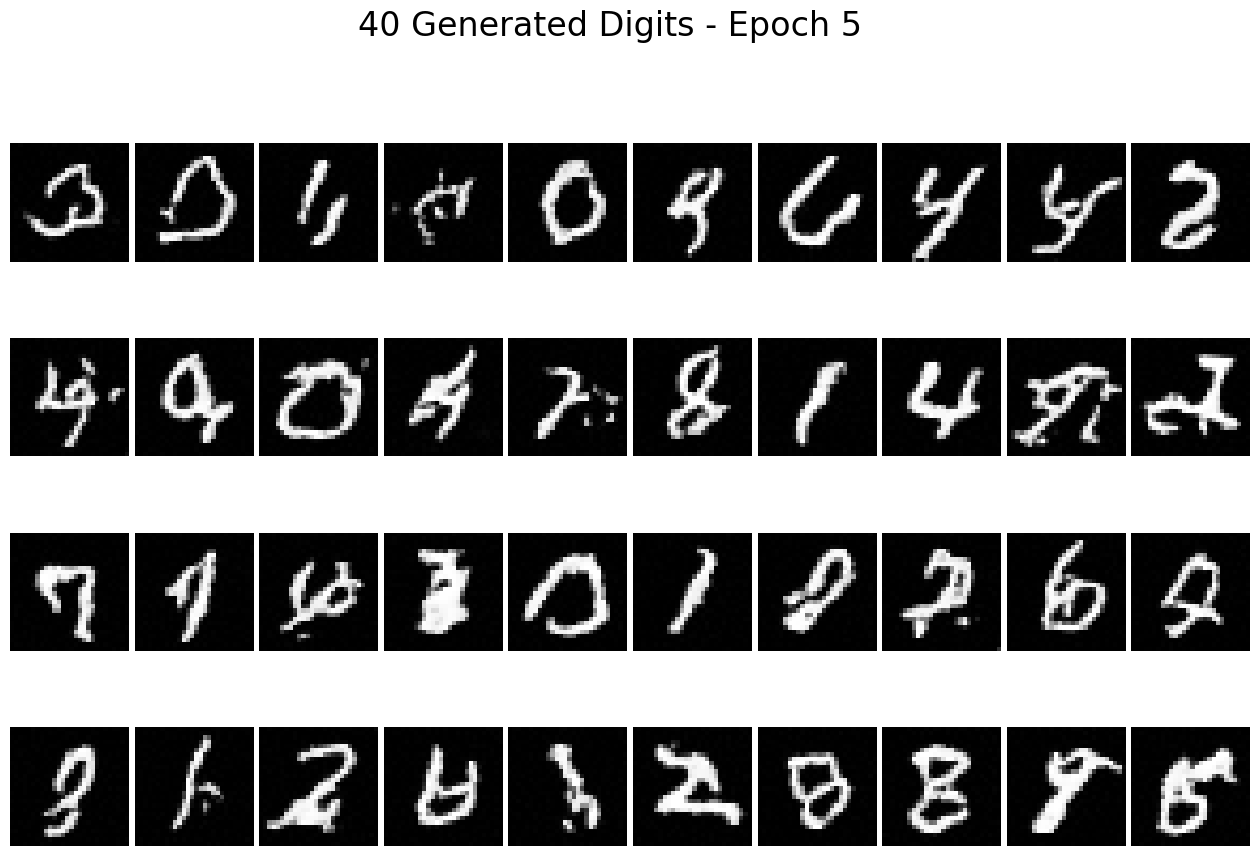

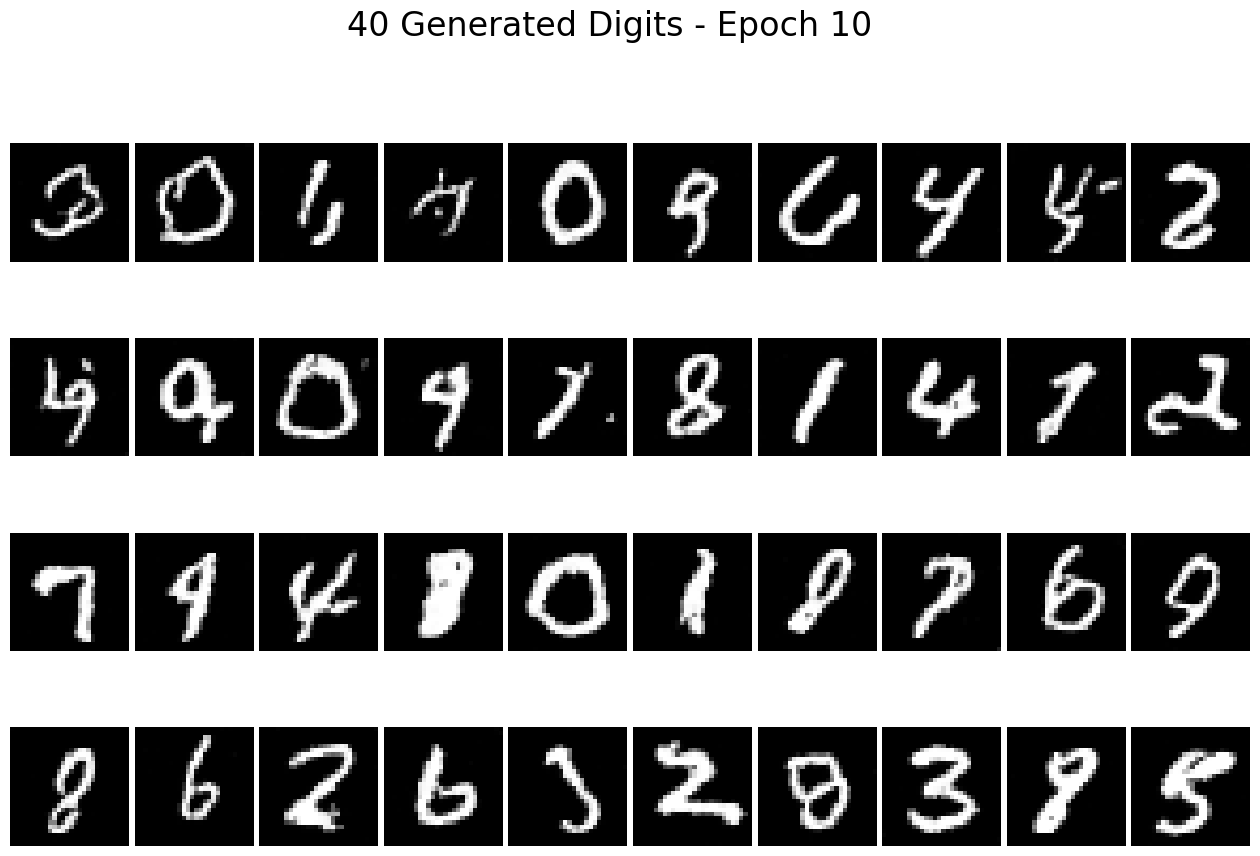

In [ ]:
print("\nGenerating samples from checkpoints...")
num_samples_to_generate = 40
for epoch in checkpoint_epochs:
    checkpoint_path = os.path.join(checkpoint_dir, f'epoch_{epoch}.pt')

    if os.path.exists(checkpoint_path):
        # Load the specific checkpoint
        checkpoint = torch.load(checkpoint_path)
        model.load_state_dict(checkpoint['model_state_dict'])

        # Generate samples
        model.eval()
        with torch.no_grad():
            samples = []
            for seed in range(num_samples_to_generate):
                sample = time_fm_sample(model, img_wh=(28, 28), num_ts=50, seed=seed)
                samples.append(sample)

            samples_batch = torch.cat(samples, dim=0)
            sampling_results[epoch] = samples_batch.cpu()

        print(f"Generated {num_samples_to_generate} samples from epoch {epoch}")

# Visualize 40 samples per epoch
for epoch in checkpoint_epochs:
    if epoch in sampling_results:
        samples = sampling_results[epoch]
        samples = torch.clamp(samples, 0, 1)

        # Create 5x8 grid for 40 samples
        n_rows, n_cols = 4, 10

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 10))
        axes_flat = axes.flatten()

        for i in range(40):
            axes_flat[i].imshow(samples[i].squeeze(), cmap='gray', vmin=0, vmax=1)
            axes_flat[i].axis('off')

        plt.subplots_adjust(wspace=0.05, hspace=0.05)
        plt.suptitle(f'40 Generated Digits - Epoch {epoch}', fontsize=24, y=0.98)
        plt.show()

# Part 2.3: Sampling from the Time-conditioned UNet

In [ ]:
# Sampling from the UNet
# ===== your code here! ====

# ===== end of code ====

# Part 2.4: Implementing a Class-conditioned UNet

In [ ]:
class ClassConditionalUNet(nn.Module):
    def __init__(
        self,
        in_channels: int,
        num_classes: int,
        num_hiddens: int,
    ):
        super().__init__()
        super().__init__()
        # ===== your code here! ====
        D = num_hiddens
        self.inc = ConvBlock(in_channels, D)
        self.down1 = DownBlock(D, D)
        self.down2 = DownBlock(D, 2*D)
        self.flatten = Flatten()
        self.unflatten = Unflatten(2*D)
        self.up1 = UpBlock(4*D, D)
        self.up2 = UpBlock(2*D, D)
        self.outc = ConvBlock(2*D, D)
        self.final = nn.Conv2d(D, in_channels, kernel_size=3, stride=1, padding=1)

        self.fc2 = FCBlock(1, D)
        self.fc1 = FCBlock(1, 2 * D)
        #=============2.4=======================
        self.f1_c = FCBlock(num_classes, 2 * D)
        self.f2_c = FCBlock(num_classes, D)
        self.num_classes = num_classes


    def forward(
        self,
        x: torch.Tensor,
        c: torch.Tensor,
        t: torch.Tensor,
        mask: torch.Tensor | None = None,
    ) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            c: (N,) int64 condition tensor.
            t: (N,) normalized time tensor.
            mask: (N,) mask tensor. If not None, mask out condition when mask == 0.

        Returns:
            (N, C, H, W) output tensor.
        """
        assert x.shape[-2:] == (28, 28), "Expect input shape to be (28, 28)."
        t = t.unsqueeze(-1)

        if mask is not None:
            mask = mask.view(-1, 1)
            c = c * mask

        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        flat = self.flatten(x3)
        unflat = self.unflatten(flat)

        t1 = self.fc1(t).unsqueeze(-1).unsqueeze(-1)
        t2 = self.fc2(t).unsqueeze(-1).unsqueeze(-1)

        #=====================2.4==================

        c1 = self.f1_c(c).unsqueeze(-1).unsqueeze(-1)
        c2 = self.f2_c(c).unsqueeze(-1).unsqueeze(-1)

        unflat = unflat * c1 + t1
        #======================2.4=====================
        #unflat = unflat * t1
        cat6 = torch.cat([unflat, x3], dim=1)
        x7 = self.up1(cat6)
        x7 = c2 * x7 + t2
        #x7 = x7 * t2

        cat8 = torch.cat([x2, x7], dim=1)
        x9 = self.up2(cat8)
        cat10 = torch.cat([x1, x9], dim=1)
        x11 = self.outc(cat10)
        x12 = self.final(x11)
        return x12

In [ ]:
import torch.nn.functional as F

def class_fm_forward(
    unet: ClassConditionalUNet,
    x_1: torch.Tensor,
    c: torch.Tensor,
    p_uncond: float,
    num_ts: int,
) -> torch.Tensor:
    """Algorithm 3

    Args:
        unet: ClassConditionalUNet
        x_1: (N, C, H, W) input tensor.
        c: (N,) int64 condition tensor.
        p_uncond: float, probability of unconditioning the condition.
        num_ts: int, number of timesteps.

    Returns:
        (,) loss.
    """
    unet.train()
    # ===== your code here! ====
    batch_size = x_1.shape[0]
    device = x_1.device
    c_one_hot = F.one_hot(c, num_classes=unet.num_classes).float()

    mask = (torch.rand(batch_size, device=device) > p_uncond).float()
    mask = mask.unsqueeze(-1)
    c_conditioned = c_one_hot * mask


    t = torch.rand(batch_size, device=device)
    x_0 = torch.randn_like(x_1)
    x_t = (1 - t.view(-1, 1, 1, 1)) * x_0 + t.view(-1, 1, 1, 1) * x_1
    true_float = x_1 - x_0
    predicted_flow = unet(x_t, c_conditioned, t)
    loss = torch.mean((predicted_flow - true_float) ** 2)
    return loss


In [ ]:
@torch.inference_mode()
def class_fm_sample(
    unet: ClassConditionalUNet,
    c: torch.Tensor,
    img_wh: tuple[int, int],
    num_ts: int,
    guidance_scale: float = 5.0,
    seed: int = 0,
) -> torch.Tensor:
    """Algorithm 4

    Args:
        unet: ClassConditionalUNet
        c: (N,) int64 condition tensor. Only for class-conditional
        img_wh: (H, W) output image width and height.
        num_ts: int, number of timesteps.
        guidance_scale: float, CFG scale.
        seed: int, random seed.

    Returns:
        (N, C, H, W) final sample.
        (N, T_animation, C, H, W) caches.
    """
    unet.eval()
    # ===== your code here! ====

    if seed is not None:
        torch.manual_seed(seed)

    H, W = img_wh
    device = next(unet.parameters()).device

    # Ensure c is LongTensor
    c = c.long()
    N = len(c) if hasattr(c, '__len__') else 1

    x_t = torch.randn(N, 1, H, W, device=device)

    c_one_hot = F.one_hot(c, num_classes=unet.num_classes).float().to(device)
    c_uncond = torch.zeros_like(c_one_hot)

    dt = 1.0 / num_ts
    for i in range(num_ts):
        t_val = i * dt
        t_tensor = torch.full((N,), t_val, device=device)

        # Pass ONE-HOT vectors to UNet, not integer labels!
        u_cond = unet(x_t, c_one_hot, t_tensor)  # c_one_hot, not c
        u_uncond = unet(x_t, c_uncond, t_tensor)

        u = u_uncond + guidance_scale * (u_cond - u_uncond)
        x_t = x_t + u * dt

    return x_t
    # ===== end of code ====


In [ ]:
class ClassConditionalFM(nn.Module):
    def __init__(
        self,
        unet: ClassConditionalUNet,
        num_ts: int = 300,
        p_uncond: float = 0.1,
    ):
        super().__init__()
        self.unet = unet
        self.num_ts = num_ts
        self.p_uncond = p_uncond

    def forward(self, x: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (N, C, H, W) input tensor.
            c: (N,) int64 condition tensor.

        Returns:
            (,) loss.
        """
        return class_fm_forward(
            self.unet, x, c, self.p_uncond, self.num_ts
        )

    @torch.inference_mode()
    def sample(
        self,
        c: torch.Tensor,
        img_wh: tuple[int, int],
        guidance_scale: float = 5.0,
        seed: int = 0,
    ):
        return class_fm_sample(
            self.unet, c, img_wh, self.num_ts, guidance_scale, seed
        )

# Part 2.5 Training the Class-conditioned UNet

In [ ]:
import torchvision
import torch.optim as optim

device = torch.device('cuda')

# Set your hyperparameters
batch_size = 64
learning_rate = 1e-2
hidden_dim = 64
num_epochs = 10
#gamma = 0.1**(1.0/num_epochs)
p_uncond = 0.1

# Define your datasets and dataloaders
transform = transforms.Compose([
    transforms.ToTensor(),
])
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
# ===== end of code ====
# Define your model, optimizer, and loss
# ===== your code here! ====
model = ClassConditionalUNet(in_channels=1, num_classes=10, num_hiddens=hidden_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
#scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)
criterion = nn.MSELoss()
# ===== end of code ====

In [ ]:
import matplotlib.pyplot as plt

def visualize_during_training(model, epoch, device, num_samples=40, seed_offset=0):
    """
    Visualize generated samples during training.

    Args:
        model: The ClassConditionalUNet model
        epoch: Current epoch number
        device: torch device
        num_samples: Number of samples to generate (default: 40)
        seed_offset: Offset for seed to vary samples across calls
    """
    model.eval()
    with torch.no_grad():
        samples = []
        # Generate samples for visualization
        for i in range(num_samples):
            class_label = i % 10  # Cycle through digits 0-9
            c = torch.tensor([class_label], device=device)

            # Generate sample with deterministic seed for reproducibility
            seed = epoch * 1000 + seed_offset + i
            sample = class_fm_sample(model, c=c, img_wh=(28, 28), num_ts=50, seed=seed)
            samples.append(sample)

        samples_batch = torch.cat(samples, dim=0)
        samples_batch = torch.clamp(samples_batch.cpu(), 0, 1)

    # Create visualization
    n_rows, n_cols = 4, 10
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 10))
    axes_flat = axes.flatten()

    for i in range(num_samples):
        axes_flat[i].imshow(samples_batch[i].squeeze(), cmap='gray', vmin=0, vmax=1)
        axes_flat[i].axis('off')
        axes_flat[i].set_title(f'{i % 10}', fontsize=8, y=0.9)

    plt.subplots_adjust(wspace=0.05, hspace=0.05)
    plt.suptitle(f'Generated Digits - Epoch {epoch}', fontsize=24, y=0.98)
    plt.tight_layout()

    # Use non-blocking show
    plt.show(block=False)
    plt.pause(0.1)

    # Save the figure if needed
    os.makedirs('./samples_no_scheduler', exist_ok=True)
    plt.savefig(f'./samples_no_scheduler/epoch_{epoch}.png', dpi=100, bbox_inches='tight')

    plt.close(fig)

    # Return to training mode
    model.train()

    return samples_batch

Starting flow matching training...


Epoch 1/10:   0%|          | 2/938 [00:00<00:58, 16.08it/s]

Epoch 1, Batch 0, Loss: 1.520979


Epoch 1/10:  11%|█         | 103/938 [00:04<00:35, 23.25it/s]

Epoch 1, Batch 100, Loss: 0.209902


...

Epoch 1, Batch 800, Loss: 0.111603


Epoch 1/10:  96%|█████████▋| 904/938 [00:39<00:01, 23.03it/s]

Epoch 1, Batch 900, Loss: 0.110300


Epoch 1/10: 100%|██████████| 938/938 [00:41<00:00, 22.69it/s]


Epoch 1 completed. Average Loss: 0.186464

Epoch 1: Generating samples for visualization...


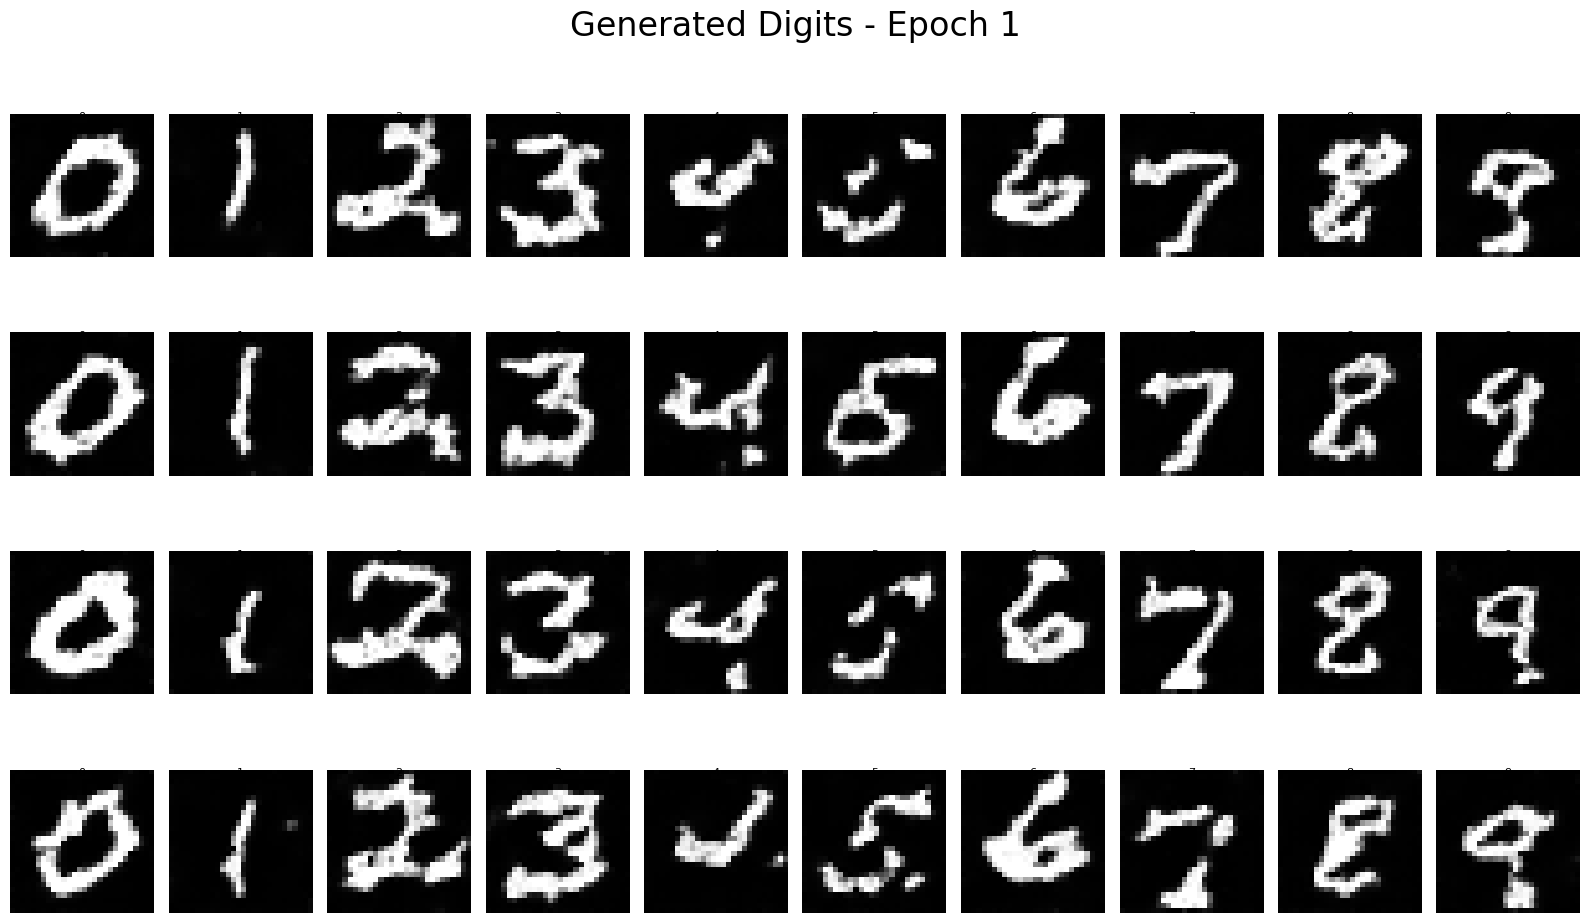

Checkpoint saved at ./checkpoints_no_scheduler/epoch_1.pt


Epoch 2/10:   0%|          | 4/938 [00:00<00:47, 19.61it/s]

Epoch 2, Batch 0, Loss: 0.121478


Epoch 2/10:  11%|█         | 103/938 [00:04<00:36, 22.94it/s]

Epoch 2, Batch 100, Loss: 0.106865


...

Epoch 5/10:  96%|█████████▋| 903/938 [00:40<00:01, 22.70it/s]

Epoch 5, Batch 900, Loss: 0.096514


Epoch 5/10: 100%|██████████| 938/938 [00:41<00:00, 22.44it/s]


Epoch 5 completed. Average Loss: 0.094842

Epoch 5: Generating samples for visualization...


<Figure size 640x480 with 0 Axes>

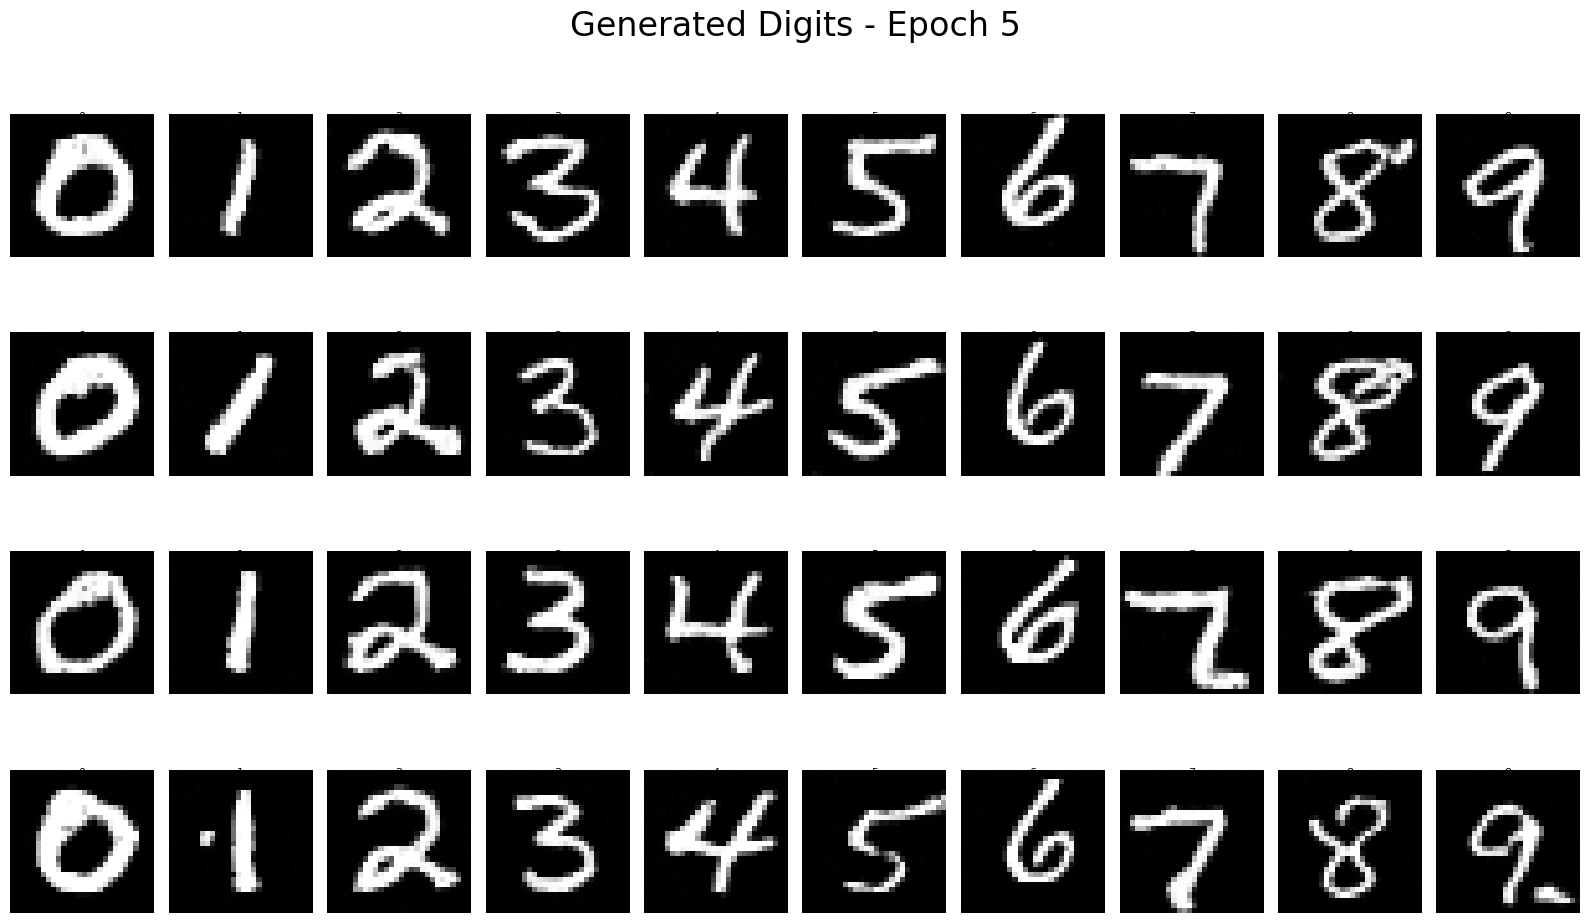

Checkpoint saved at ./checkpoints_no_scheduler/epoch_5.pt


Epoch 6/10:   1%|          | 5/938 [00:00<00:47, 19.80it/s]

Epoch 6, Batch 0, Loss: 0.088418


Epoch 6/10:  11%|█         | 104/938 [00:04<00:36, 22.84it/s]

Epoch 6, Batch 100, Loss: 0.086104


...

Epoch 10/10:  96%|█████████▋| 903/938 [00:40<00:01, 20.67it/s]

Epoch 10, Batch 900, Loss: 0.084643


Epoch 10/10: 100%|██████████| 938/938 [00:42<00:00, 22.23it/s]


Epoch 10 completed. Average Loss: 0.087200

Epoch 10: Generating samples for visualization...


<Figure size 640x480 with 0 Axes>

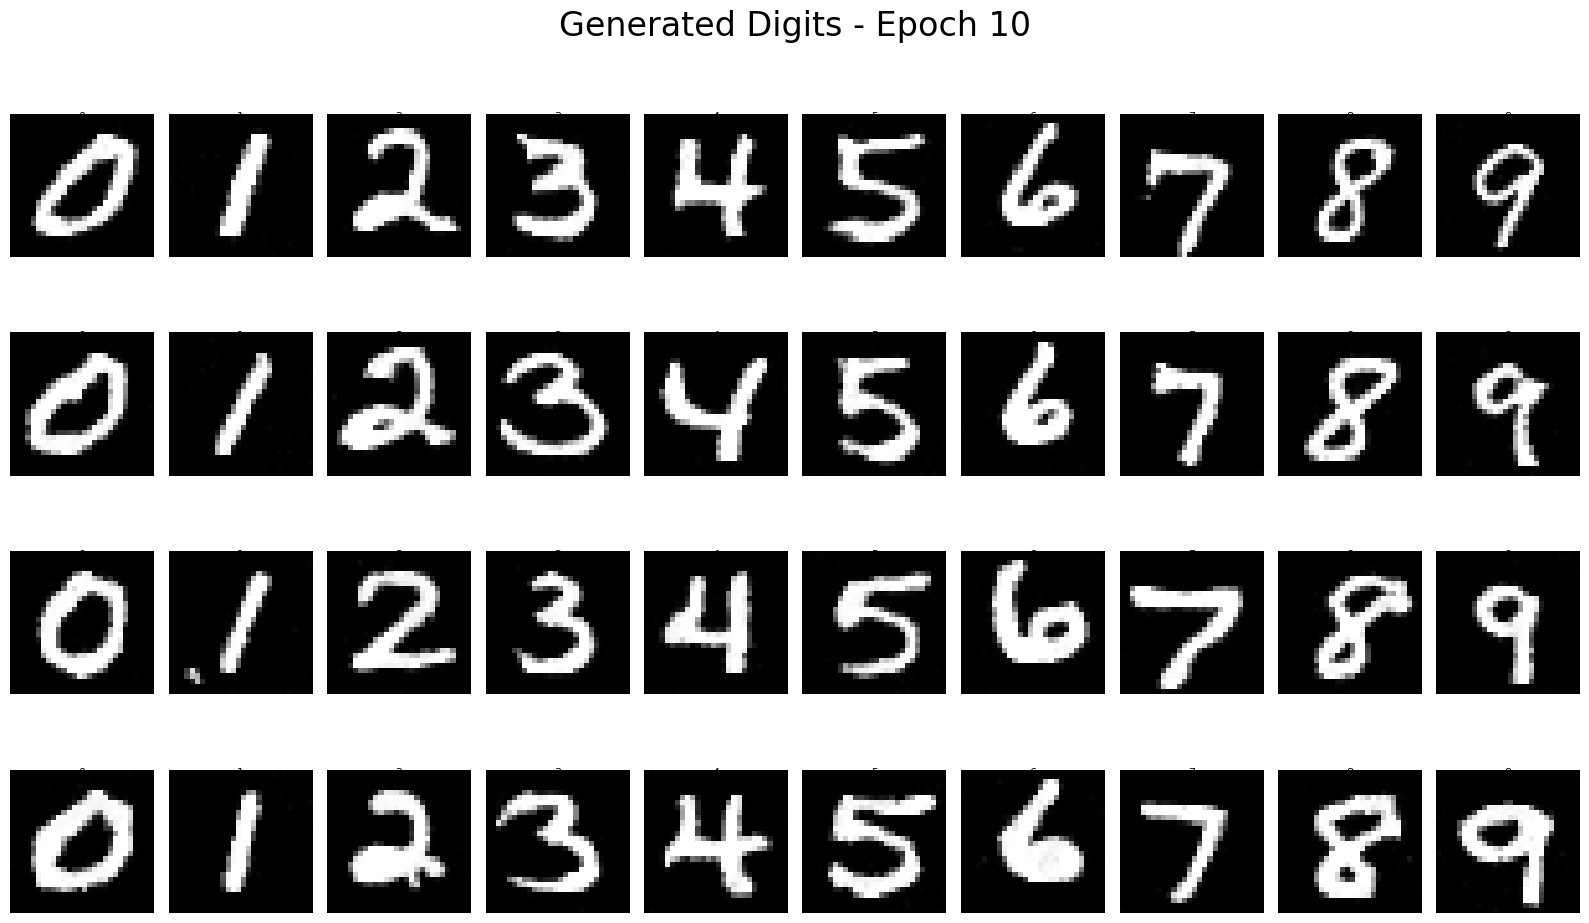

Checkpoint saved at ./checkpoints_no_scheduler/epoch_10.pt


<Figure size 640x480 with 0 Axes>

In [ ]:
import os
import torch

checkpoint_dir = './checkpoints_no_scheduler'
os.makedirs(checkpoint_dir, exist_ok=True)

checkpoint_epochs = [1, 5, 10]
num_samples_to_generate = 40
sampling_results = {}


train_losses = []
print("Starting flow matching training...")

for epoch in range(num_epochs):
    model.train()
    epoch_losses = []

    for i, (images, labels) in enumerate(tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')):
        images = images.to(device)
        labels = labels.to(device)
        loss = class_fm_forward(model, images, labels, p_uncond =p_uncond, num_ts=50)

        # ===== END FLOW MATCHING =====

        optimizer.zero_grad()
        loss.backward()
        #torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_losses.append(loss.item())
        epoch_losses.append(loss.item())

        if i % 100 == 0:
            #print(f'Epoch {epoch+1}, Batch {i}, Loss: {loss.item():.6f}, LR: {scheduler.get_last_lr()[0]:.6f}')
            print(f'Epoch {epoch+1}, Batch {i}, Loss: {loss.item():.6f}')
    #scheduler.step()

    avg_epoch_loss = sum(epoch_losses) / len(epoch_losses)
    #print(f'Epoch {epoch+1} completed. Average Loss: {avg_epoch_loss:.6f}, LR: {scheduler.get_last_lr()[0]:.6f}')
    print(f'Epoch {epoch+1} completed. Average Loss: {avg_epoch_loss:.6f}')
    if (epoch + 1) % visualization_freq == 0 or epoch == 0:
        print(f"\nEpoch {epoch + 1}: Generating samples for visualization...")
        visualize_during_training(model, epoch + 1, device, num_samples=40)
    # Visualization
    if (epoch + 1) in checkpoint_epochs:
        checkpoint_path = os.path.join(checkpoint_dir, f'epoch_{epoch+1}.pt')
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            #'optimizer_state_dict': optimizer.state_dict(),
            #'scheduler_state_dict': scheduler.state_dict(),
            'loss': avg_epoch_loss,
        }, checkpoint_path)
        print(f"Checkpoint saved at {checkpoint_path}")

        model.eval()
        with torch.no_grad():
            samples = []
            for class_label in range(10):
                c = torch.tensor([class_label], device=device)
                sample = class_fm_sample(model, c=c, img_wh=(28, 28), num_ts=50)
                samples.append(sample)

            samples_batch = torch.cat(samples, dim=0)
            sampling_results[epoch + 1] = samples_batch.cpu()

        model.train()

# Part 2.6: Sampling from the Class-conditioned UNet

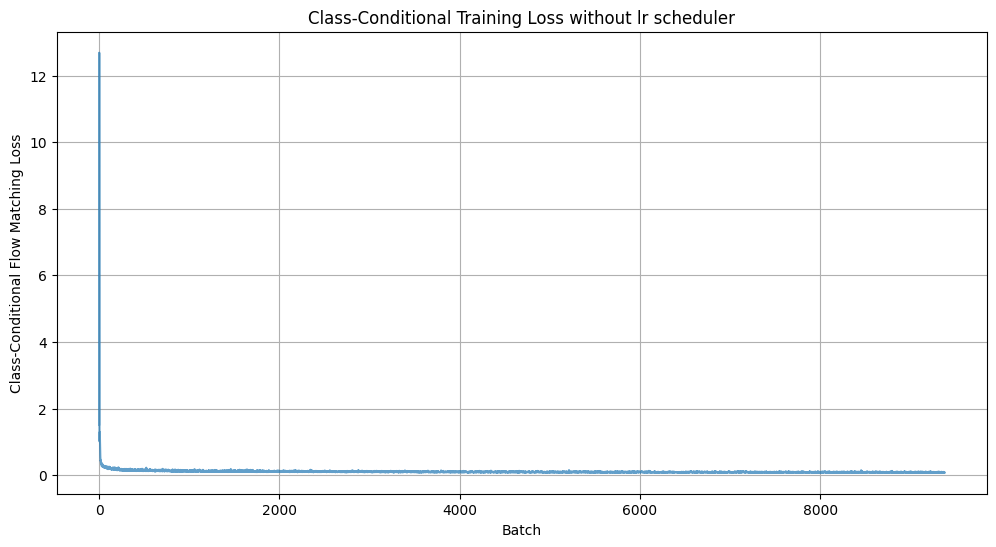

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(train_losses, alpha=0.7)
plt.xlabel('Batch')
plt.ylabel('Class-Conditional Flow Matching Loss')
plt.title('Class-Conditional Training Loss without lr scheduler')
plt.grid(True)
plt.show()


Generating samples from checkpoints...
Generated 40 samples from epoch 1
Generated 40 samples from epoch 5
Generated 40 samples from epoch 10


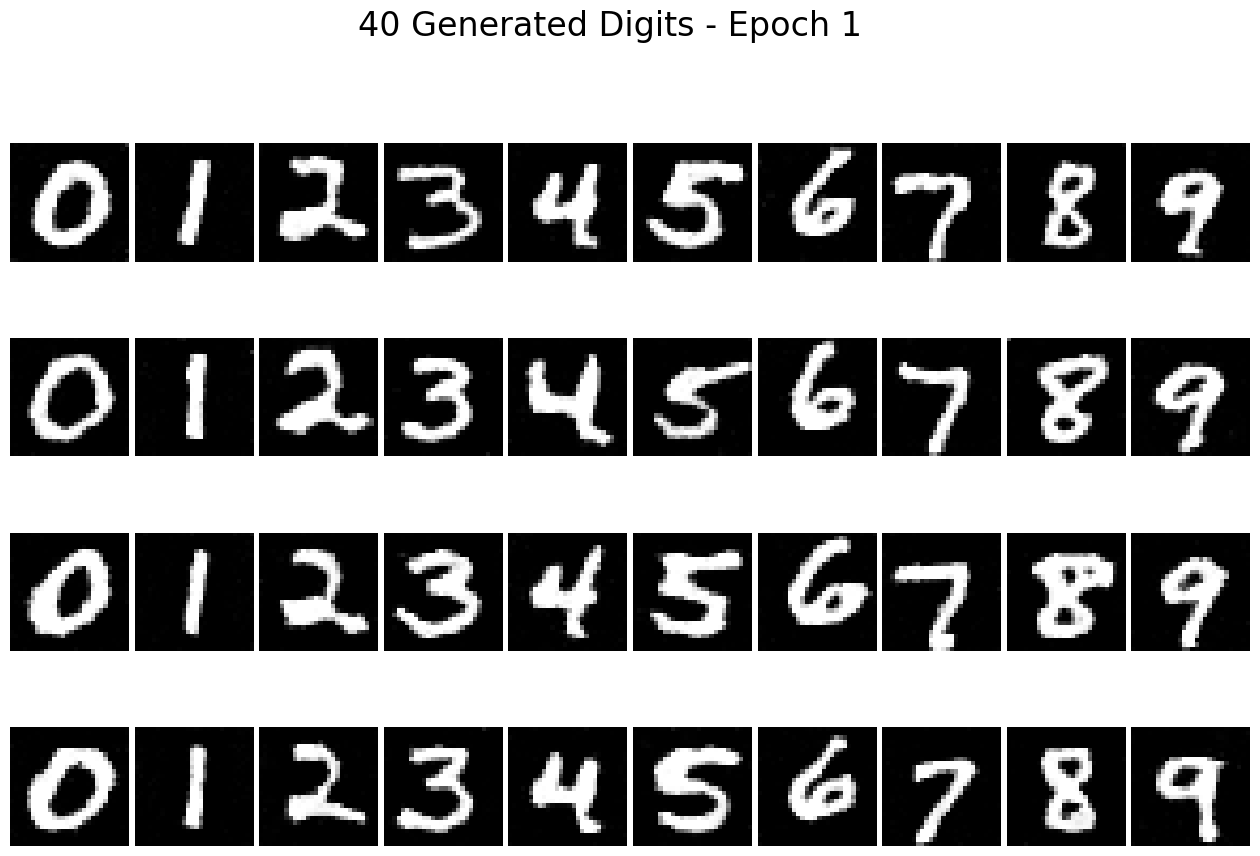

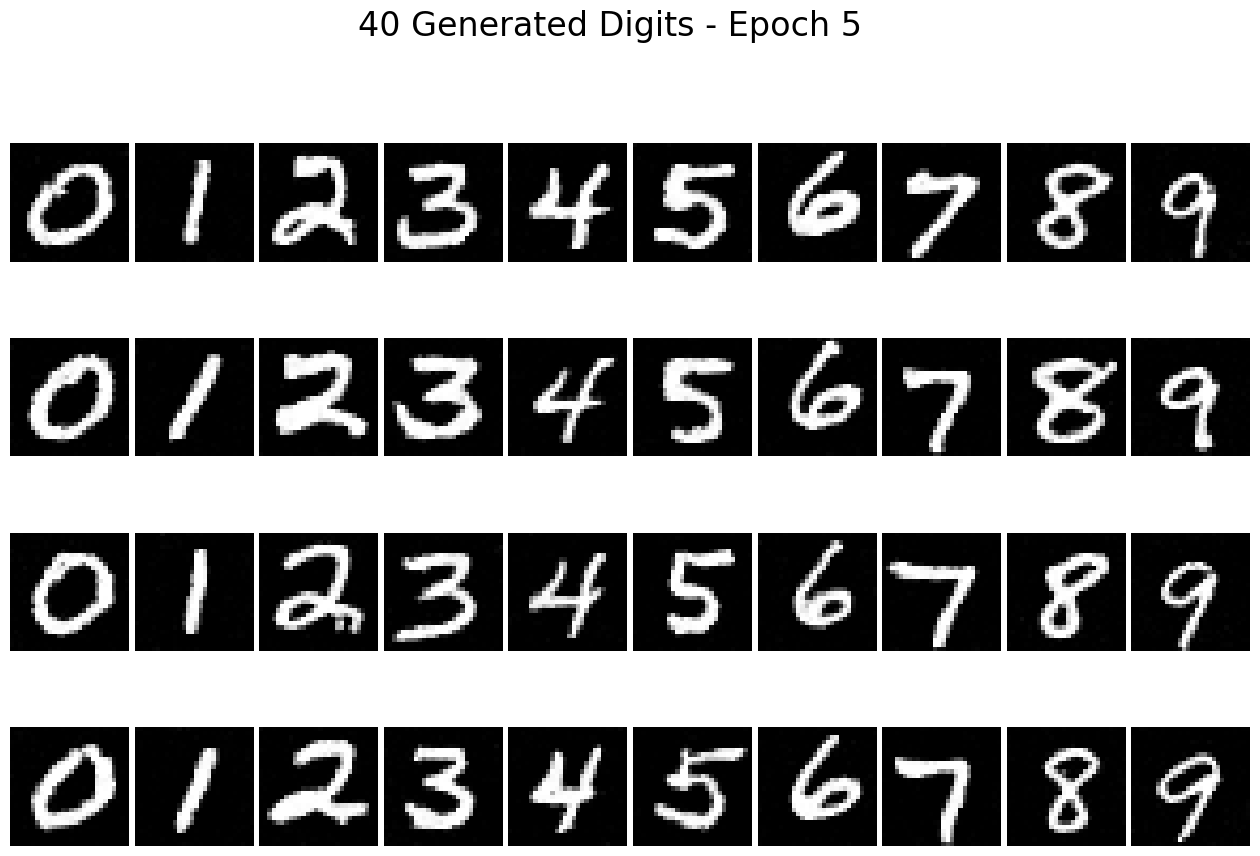

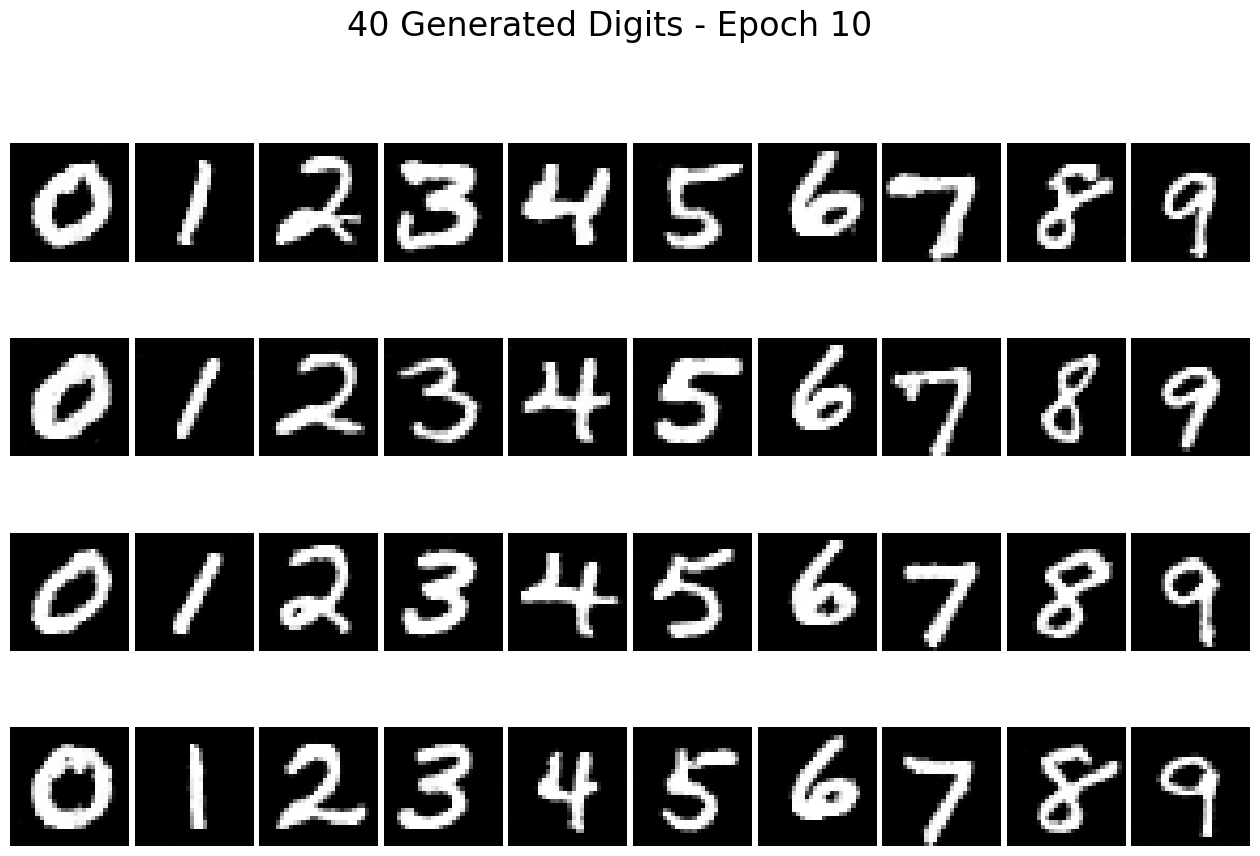

In [ ]:
print("\nGenerating samples from checkpoints...")
num_samples_to_generate = 40

for epoch in checkpoint_epochs:
    checkpoint_path = os.path.join(checkpoint_dir, f'epoch_{epoch}.pt')

    if os.path.exists(checkpoint_path):
        # Load the specific checkpoint
        checkpoint = torch.load(checkpoint_path)
        model.load_state_dict(checkpoint['model_state_dict'])

        # Generate samples
        model.eval()
        with torch.no_grad():
            samples = []
            for i in range(num_samples_to_generate):
                class_label = i % 10  # Cycle through digits 0-9
                c = torch.tensor([class_label], device=device)

                # Generate sample with class condition, no fixed seed
                sample = class_fm_sample(model, c=c, img_wh=(28, 28), num_ts=50, seed=None)
                samples.append(sample)

            samples_batch = torch.cat(samples, dim=0)
            sampling_results[epoch] = samples_batch.cpu()

        print(f"Generated {num_samples_to_generate} samples from epoch {epoch}")

for epoch in checkpoint_epochs:
    if epoch in sampling_results:
        samples = sampling_results[epoch]
        samples = torch.clamp(samples, 0, 1)

        # Create 4x10 grid for 40 samples
        n_rows, n_cols = 4, 10

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 10))
        axes_flat = axes.flatten()

        for i in range(40):
            axes_flat[i].imshow(samples[i].squeeze(), cmap='gray', vmin=0, vmax=1)
            axes_flat[i].axis('off')

        plt.subplots_adjust(wspace=0.05, hspace=0.05)
        plt.suptitle(f'40 Generated Digits - Epoch {epoch}', fontsize=24, y=0.98)
        plt.show()